In [1]:
!pip install --upgrade google-genai pillow

   ---------------------------------------- 0.0/732.2 kB ? eta -:--:--
   ---------------------------------------- 732.2/732.2 kB 3.8 MB/s eta 0:00:00
   ---------------------------------------- 0.0/7.0 MB ? eta -:--:--
   ----------- ---------------------------- 2.1/7.0 MB 11.8 MB/s eta 0:00:01
   -------------------------- ------------- 4.7/7.0 MB 11.4 MB/s eta 0:00:01
   -------------------------------------- - 6.8/7.0 MB 11.7 MB/s eta 0:00:01
   ---------------------------------------- 7.0/7.0 MB 10.8 MB/s eta 0:00:00

   ---------------------------------------- 0/4 [websockets]
  Attempting uninstall: pillow
   ---------------------------------------- 0/4 [websockets]
    Found existing installation: pillow 11.3.0
   ---------------------------------------- 0/4 [websockets]
   ---------- ----------------------------- 1/4 [pillow]
    Uninstalling pillow-11.3.0:
   ---------- ----------------------------- 1/4 [pillow]
      Successfully uninstalled pillow-11.3.0
   ---------- -----

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.48.1 requires pillow<12,>=7.1.0, but you have pillow 12.1.1 which is incompatible.


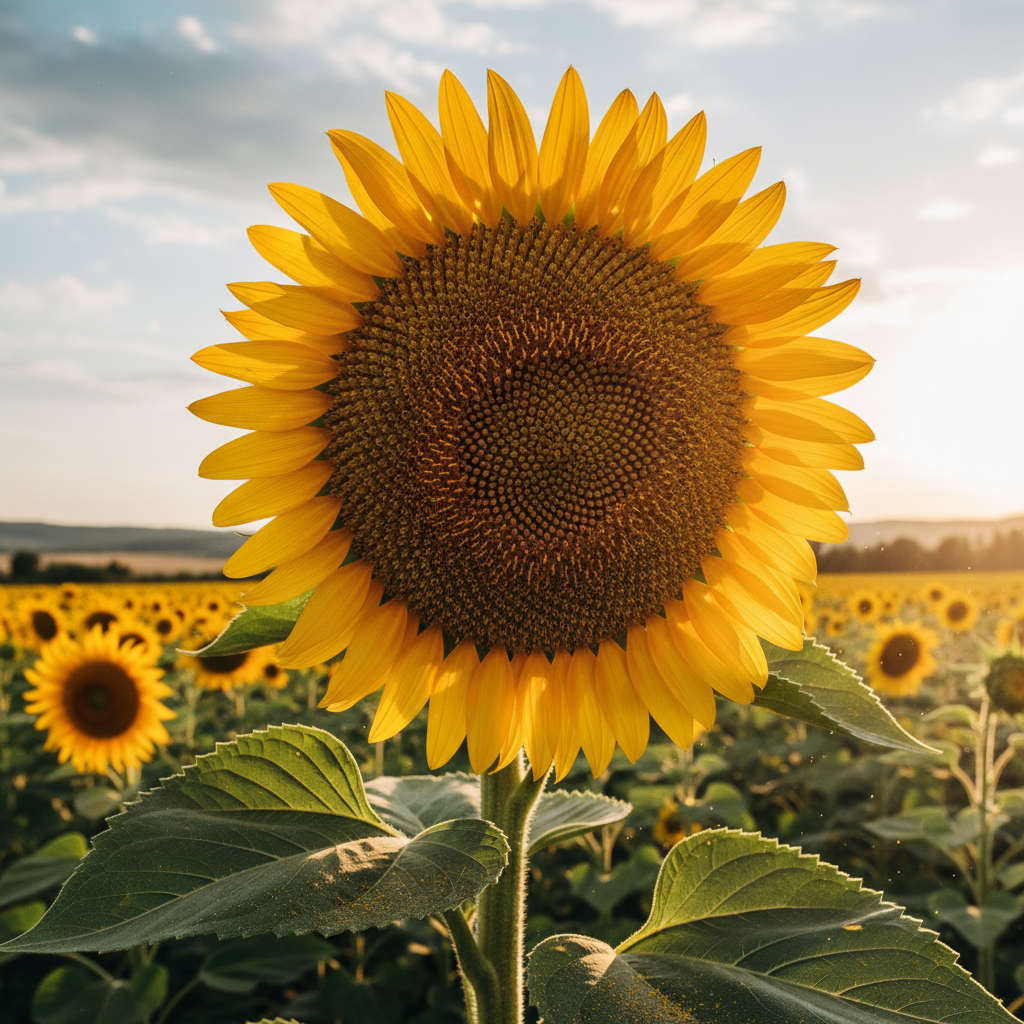

In [ ]:
from google import genai
from PIL import Image
from io import BytesIO
import base64

# Create client
client = genai.Client(api_key="your-api-key")

# Generate image
response = client.models.generate_content(
    model="gemini-2.5-flash-image",
    contents="Create an image of sunflower"
)

# Loop through parts safely
for part in response.candidates[0].content.parts:
    if hasattr(part, "inline_data") and part.inline_data is not None:
        image_bytes = part.inline_data.data
        image = Image.open(BytesIO(image_bytes))
        image.save("generated_image.png")
        display(image)